In [1]:


import torch
from torch import nn
import numpy as np

import matplotlib.pyplot as plt
import imageio

from sklearn.datasets import make_moons

import math

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device=device)

In [3]:

def sample_checkerboard(batch_size):
    x1 = torch.rand(batch_size) * 4 - 2
  
    x2_ = torch.rand(batch_size) - torch.randint(0, 2, (batch_size,)) * 2
    x2 = (x2_ + (torch.floor(x1) % 2))
    
    data = (torch.stack([x1, x2], dim=1) * 2.0 )
    return data

def sample_single_gauss(batch_size, center=(0.0, 0.0), var=1.0):
    """
    Sinh mẫu 2D Gaussian quanh một điểm.
    
    batch_size : số mẫu cần sinh
    center     : tuple (x_center, y_center) - tọa độ trung tâm
    var        : variance chung cho cả x và y
    """
    std = var**0.5
    center = torch.tensor(center, dtype=torch.float32)
    samples = center + std * torch.randn(batch_size, 2)
    return samples


def sample_symmetric_gauss(batch_size, n_gauss=4, distance=3.0, var=0.5, center=[0.0, 0.0]):
    """
    Sinh mẫu từ n Gaussian 2D đối xứng quanh gốc.
    
    batch_size : số mẫu cần sinh
    n_gauss    : số Gaussian đối xứng
    mean       : khoảng cách trung bình từ gốc đến mỗi Gaussian (bán kính)
    var        : variance chung cho tất cả Gaussian
    """
    std = var**0.5
    # chọn Gaussian cho từng sample
    comp_ids = torch.randint(0, n_gauss, (batch_size,))
    
    # đặt mean trên vòng tròn bán kính 'mean'
    angles = torch.linspace(0, 2*math.pi * (1.0 - 1.0/(n_gauss)), steps=n_gauss, dtype=torch.float32)
    gauss_means = torch.stack([ torch.cos(angles + math.pi/2), torch.sin(angles + math.pi/2)], dim=1) * distance + torch.Tensor(center).to(device=device)
    
    # sinh mẫu
    samples = gauss_means[comp_ids] + std * torch.randn(batch_size, 2)
    return samples



In [4]:
def  sample_source(size, **args):
    return sample_symmetric_gauss(size, n_gauss=2, center=[-5.0, 0.0], distance=5.0,var=0.5)

def sample_target(size, **args):
    return sample_symmetric_gauss(size, 2, center=[5.0, 0.0], distance=5.0, var=0.5)

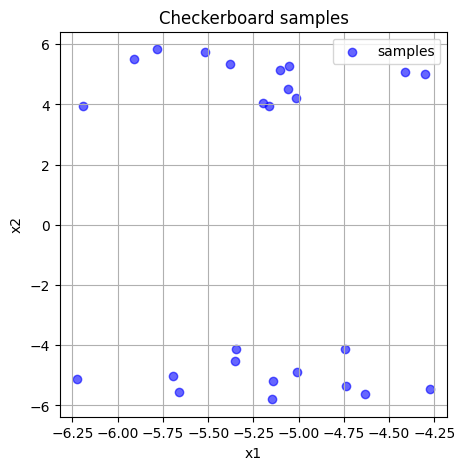

In [5]:
def show_sample(samples):
    plt.figure(figsize=(5,5))

    # Chỉ cần scatter tất cả points
    plt.scatter(samples[:,0], samples[:,1], color='blue', alpha=0.6, label='samples')

    plt.title("Checkerboard samples")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.legend()
    plt.show()

show_sample(sample_source(25).cpu())

In [6]:
class VectorFieldNetwork(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = t.view(-1, 1).expand(x.shape[0], 1)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)
    
    def step(self, x_t: torch.Tensor, t_start: torch.Tensor, t_end: torch.Tensor):
        t_start = t_start.view(1,1 ).expand(x_t.shape[0], 1)
        return x_t + (t_end - t_start) * self(x_t + self(x_t, t_start) * (t_end - t_start) / 2, t_start + (t_end - t_start) / 2)

In [ ]:
flow  = VectorFieldNetwork()
batch = 1028

optimizer = torch.optim.Adam(flow.parameters(), lr = 1e-3)
loss_fn =  nn.MSELoss()

In [8]:
# print(make_moons(batch, random_state=1, noise=0.1))

In [9]:
torch.ones(batch)

tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0')

In [10]:
epochs = 500
# des = sample_target(65536)
acc_loss = []
for _ in range(epochs):
    # x_1 = des[torch.randint(0, des.size(0), (batch,))]  
    x_1 = sample_target(batch).to(device=device) 
    x_0 = sample_source(batch).to(device=device)
    # print(x_1.shape, x_0.shape)
    
    t = torch.rand(batch, 1)
    x_t = t * x_1 + (1 - t) * x_0
    u_t = x_1 - x_0
    
    v_pred = flow(x_t, t)
    loss = loss_fn(v_pred.flatten(), u_t.flatten())
    # print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    acc_loss.append(loss.item())
    if ( (_ + 1) % 100 == 0):
        print(f"Epoch {_ + 1}, Loss: {sum(acc_loss)/len(acc_loss):.4f}")

Epoch 100, Loss: 37.6267
Epoch 200, Loss: 27.2261
Epoch 300, Loss: 21.6606
Epoch 400, Loss: 18.5552
Epoch 500, Loss: 16.6361


In [17]:
steps = 100
time_steps = torch.linspace(0, 1.0, steps + 1)

x = sample_source(128)
# print(x_0)

t = 0.0

results = []
results.append(x)

for i in range(steps):
    x = flow.step(x, time_steps[i], time_steps[i + 1])
    results.append(x)

# results.append(sample_target(128))
# steps = 1.0/256
# results = solver.sample(x_0, step_size=1.0/steps,  time_grid=time_grid, return_intermediates=True)

# print("Sampled x_1:", results[:-1])

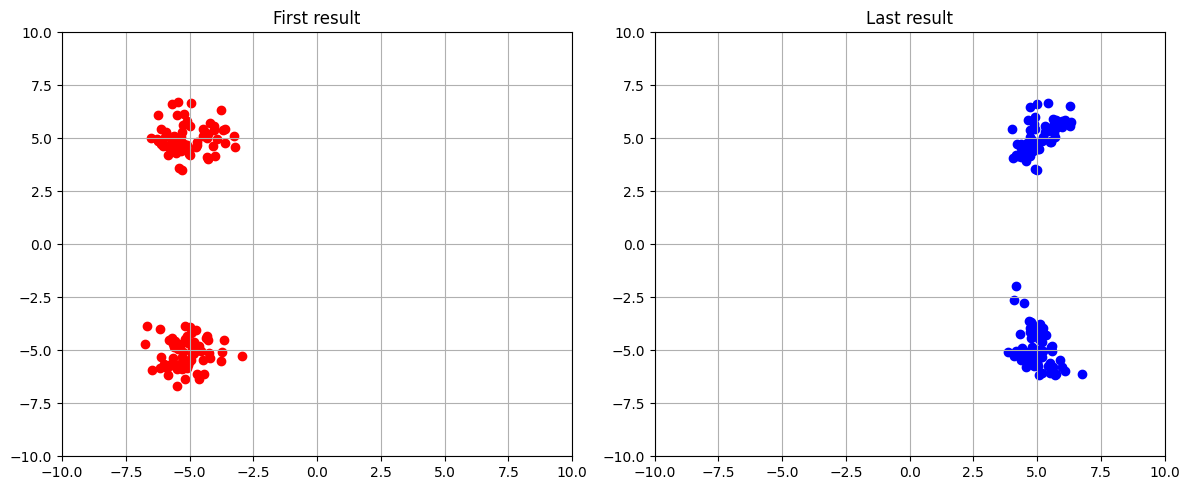

In [18]:
# Lấy result đầu tiên (giả sử là danh sách các điểm)
first_result = results[0]  # results[0] là list các điểm
last_result = results[-1]
# print(first_result)
# Nếu là tensor PyTorch


first_result_np = first_result.detach().cpu().numpy()
last_result_np = last_result.detach().cpu().numpy()

# Vẽ 2 hình cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- First result -----
axes[0].scatter(first_result_np[:,0], first_result_np[:,1], color='red')
axes[0].set_title("First result")
axes[0].set_xlim([-10, 10])
axes[0].set_ylim([-10, 10])
axes[0].grid(True)

# ----- Last result -----
axes[1].scatter(last_result_np[:,0], last_result_np[:,1], color='blue')
axes[1].set_title("Last result")
axes[1].set_xlim([-10, 10])
axes[1].set_ylim([-10, 10])
axes[1].grid(True)

plt.tight_layout()
plt.show()

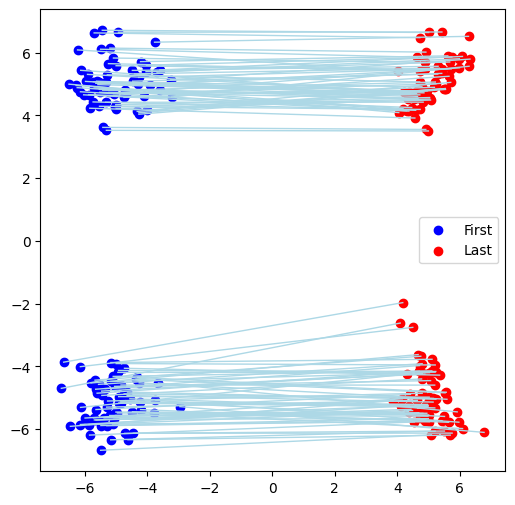

In [19]:
first = first_result_np
last = last_result_np

plt.figure(figsize=(6, 6))

# Vẽ điểm
plt.scatter(first[:, 0], first[:, 1], label='First', color='blue')
plt.scatter(last[:, 0], last[:, 1], label='Last', color='red')

# Vẽ đường nối màu xanh nhạt giữa các điểm tương ứng
for p1, p2 in zip(first, last):
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]],
             color='lightblue', linewidth=1)

plt.legend()
plt.axis('equal')
plt.show()

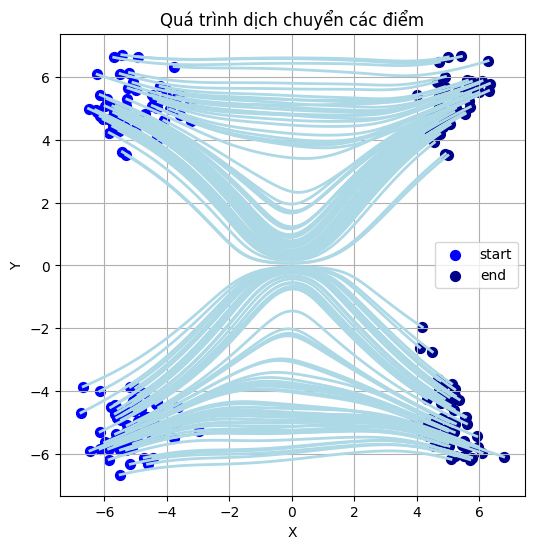

In [20]:
trajectory = torch.stack(results, dim=0)  # (steps, batch, 2)

plt.figure(figsize=(6,6))

for i in range(128):
    # kknjknkj
    path = trajectory[:, i, :].cpu().detach().numpy()
    
    plt.plot(path[:, 0], path[:, 1], color='lightblue', linewidth=2)
    
    plt.scatter(path[0, 0], path[0, 1], color='blue', s=50, label='start' if i==0 else "")
    plt.scatter(path[-1, 0], path[-1, 1], color='darkblue', s=50, label='end' if i==0 else "")

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quá trình dịch chuyển các điểm')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

In [1]:
results_cpu_list = [r.detach().cpu().numpy() for r in results]
print(results_cpu_list[0])
frames = []

for i, results_cpu in enumerate(results_cpu_list):
    fig, ax = plt.subplots(figsize=(5,5))
    
    ax.scatter(results_cpu[:,0], results_cpu[:,1], color='red', label=f'time step {i}')
    # ax.scatter(results_cpu[:,0], results_cpu[:,1], color='red', label=f'time step {i}')
    ax.legend()
    ax.set_title("ODE Sampling: Batch points over time")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.set_xlim([-4, 4])
    ax.set_ylim([-4, 4])
    
    # Lưu figure vào buffer
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    image = buf.reshape((h, w, 4))  # 4 kênh RGBA
    frames.append(image)
    plt.close(fig)

# Tạo GIF
imageio.mimsave('ode_sampling_batch.gif', frames, duration=0.01)

NameError: name 'results' is not defined

In [16]:
# Lấy dữ liệu
# samples = sample_source(100,).cpu()


